In [1]:
import torch
import numpy as np
import nugget
import pickle
import os

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


In [21]:
device="cuda:1"
string_number_penalty = nugget.losses.geometry_penalties.StringNumberPenalty(device=device)
string_boundary_penalty = nugget.losses.geometry_penalties.StringBoundaryPenaltyCircle(device=device)
weighted_binarization_penalty = nugget.losses.geometry_penalties.WeightBinarizationPenalty(device=device)
local_string_repulsion_penalty = nugget.losses.geometry_penalties.LocalStringRepulsionPenalty(device=device)

rov_penalty = nugget.losses.geometry_penalties.ROVPenalty( 
    device=device,
    rov_rec_width=230,  # ROV dimensions
    rov_height=160, 
    rov_tri_length=160
)
light_yield_loss = nugget.losses.light_yield.LightYieldLoss(device=device)

num_strings = 61

# if folder does not exist, create it
light_yield_surrogate = nugget.surrogates.Uniform.Uniform(device=device, dim=3)

signal_sampler = nugget.samplers.toy_sampler.ToySampler(
    device=device,
    dim=3,
)

In [37]:

# check if there are already optimized geometries in the folder, and if so add a number to the folder name
# count = 0
# while os.path.exists(f'{folder_name}geom_{count}.pkl'):
#     count += 1

loss_params = {
    'num_events': 1,  
    'signal_surrogate_func': light_yield_surrogate,
    'signal_sampler': signal_sampler,
    'boundary_range': 1200,  # Size of boundary region
    'eva_min_num_strings': 70,  # Minimum number of active strings
    'string_number_use_binarization_weight': False,
    'max_radius': 80,  # Maximum radius for string placement
    'num_angles': 360,  # Number of angles (divided into 360 degrees) to test for rov
    'rov_alt_mode': True,  # Whether to use alternative mode for rov penalty (see rov_penalty.py for details)
    'local_sharpness': 10,  # Sharpness parameter for local string repulsion
    'boundary_sharpness': 10,  # Sharpness parameter for boundary penalty
    'string_number_beta':5,
    'detach_other_probs':False,
    'rov_soft_inside':True,
    'rov_inside_sharpness': 5,
    'rov_angle_softmin_tau': 0.1,
    'rov_angle_chunk_size': 360,
    'rov_inside_use_softplus': True,
    # 'rov_away_weight': 0.00,
    # 'rov_away_num_neighbours':5,
    # 'rov_use_torch_compile': False,
    'local_repulsion_use_torch_compile': False,
   
    'constraints_list': [
              
                'rov_penalty', 
                'string_boundary_penalty', 
                'local_string_repulsion_penalty', 
                'string_number_penalty', 
                # 'string_weights_penalty',
                # 'weight_binarization_penalty',
                # 'diversity_penalty',
                ],  # Constraints to enforce
}
loss_weights_dict = {
    'signal_yield_loss': 0.01,        # High weight: maximize light collection
    'string_boundary_penalty': 2,  # Very high: hard constraint
    'local_string_repulsion_penalty': 1,
    'string_weights_penalty': 0.05,     # Encourage sparse solutions
    'string_number_penalty': 10,      # Limit detector complexity
    'weight_binarization_penalty': 0.1,
    'rov_penalty': 1,
 

}

loss_sigmoid_list = [

    'signal_yield_loss',        
    'string_boundary_penalty', 
    'local_string_repulsion_penalty',   
    'string_weights_penalty',     
    'string_number_penalty',     
    'weight_binarization_penalty',
    'rov_penalty'
]
loss_func_dict = {
    # 'signal_yield_loss': light_yield_loss,
    'rov_penalty': rov_penalty,
    'string_boundary_penalty': string_boundary_penalty,
    'local_string_repulsion_penalty': local_string_repulsion_penalty,
}


   

  
# geometry = nugget.geometries.DynamicString.DynamicString(
#         device=device,
#         hex_type='hexagonal',
#         random_xy=False,  # Randomize initial string positions
#         domain_size=300,  # Size of detector domain
#         dim=3,  # 3D geometry
#         n_strings=num_strings,  # Initial number of detector strings
#         points_per_string=1,  # Number of PMTs/sensors per strin
#     )
geometry = nugget.geometries.NFoldString.NFoldString(
                device=device,
                domain_size=300,  # Size of detector domain
                dim=3,  # 3D geometry
                n_folds=6,
                strings_per_fold=10,
                points_per_string=20,  # Number of PMTs/sensors per string
                custom_z_spacing=50,
                use_weights=False,
                starting_weight=6,
                random_weights=False,
                slice_init = 'sunflower',
                # fold_offset=2*np.pi/3
            )

visualizer = nugget.utils.vis_tools.Visualizer(
    device=device,
    dim=3, 
    domain_size=1400,
    gif_temp_dir='./gif_temp_3',  # Directory for storing animation frames
    )

optimizer = nugget.utils.basic_optimizer.Optimizer(
    device=geometry.device, 
    geometry=geometry,
    visualizer=visualizer,
    conflict_free=False,  # Single-objective optimization (vs multi-objective)
    use_custom_cf_weight=False,
    use_alm=True,  # Use Augmented Lagrangian Method for constraints
    sigmoid_losses=True,
    sigmoid_softness=1,
    alm_params={
        'gamma': 1e-2,
        'alpha': 0.95,
        'epsilon': 1e-8,
        }
    )
optimizer.init_geometry(
    # opt_list=[('string_weights', 0.5)],  # Learning rate for string weights (without sigmoid applied)
    # opt_list=[('string_xy', 10)],  # Learning rate for string positions (without sigmoid applied)
    opt_list=[('slice_radius', 5), ('slice_angle', 0.05)] # Learning rate for slice radius and angle (without sigmoid applied
)  




Optimizing slice_radius with torch.Size([10]) shape
Optimizing slice_angle with torch.Size([10]) shape


In [38]:
plot_types = [
    'loss_components',           # Loss function values over time
   
    'string_xy',
    'string_xy_local_string_repulsion_penalty',
    'string_xy_rov_penalty',
    'string_history',
    'nn_distance_history',
    
]
# additional arguments for the visualizer
vis_kwargs = {
    'moving_average_window': 10,  # Window size for smoothing loss curves
    'moving_average_losses': ['string_boundary_penalty', 'local_string_repulsion_penalty', 'rov_penalty'],
    'plot_types': plot_types,
    'gif_plot_selection': plot_types,  # Which plots to include in animation
  
    'draw_radius': True,
    'max_radius': loss_params['boundary_range']/2,
    'rov_penalty_func': rov_penalty,
    'rov_draw_safe_space_union': True,
    'rov_union_per_space_colors':True,
    'rov_draw_safe_space_on_violations':False,
    'rov_safe_space_one_fold_only': True,
}

In [40]:
loss_dict=optimizer.loss_dict         # resupply loss histories if continuing optimization (only for visualization)
uw_loss_dict=optimizer.uw_loss_dict  
vis_loss_dict=optimizer.vis_loss_dict
vis_uw_loss_dict=optimizer.vis_uw_loss_dict

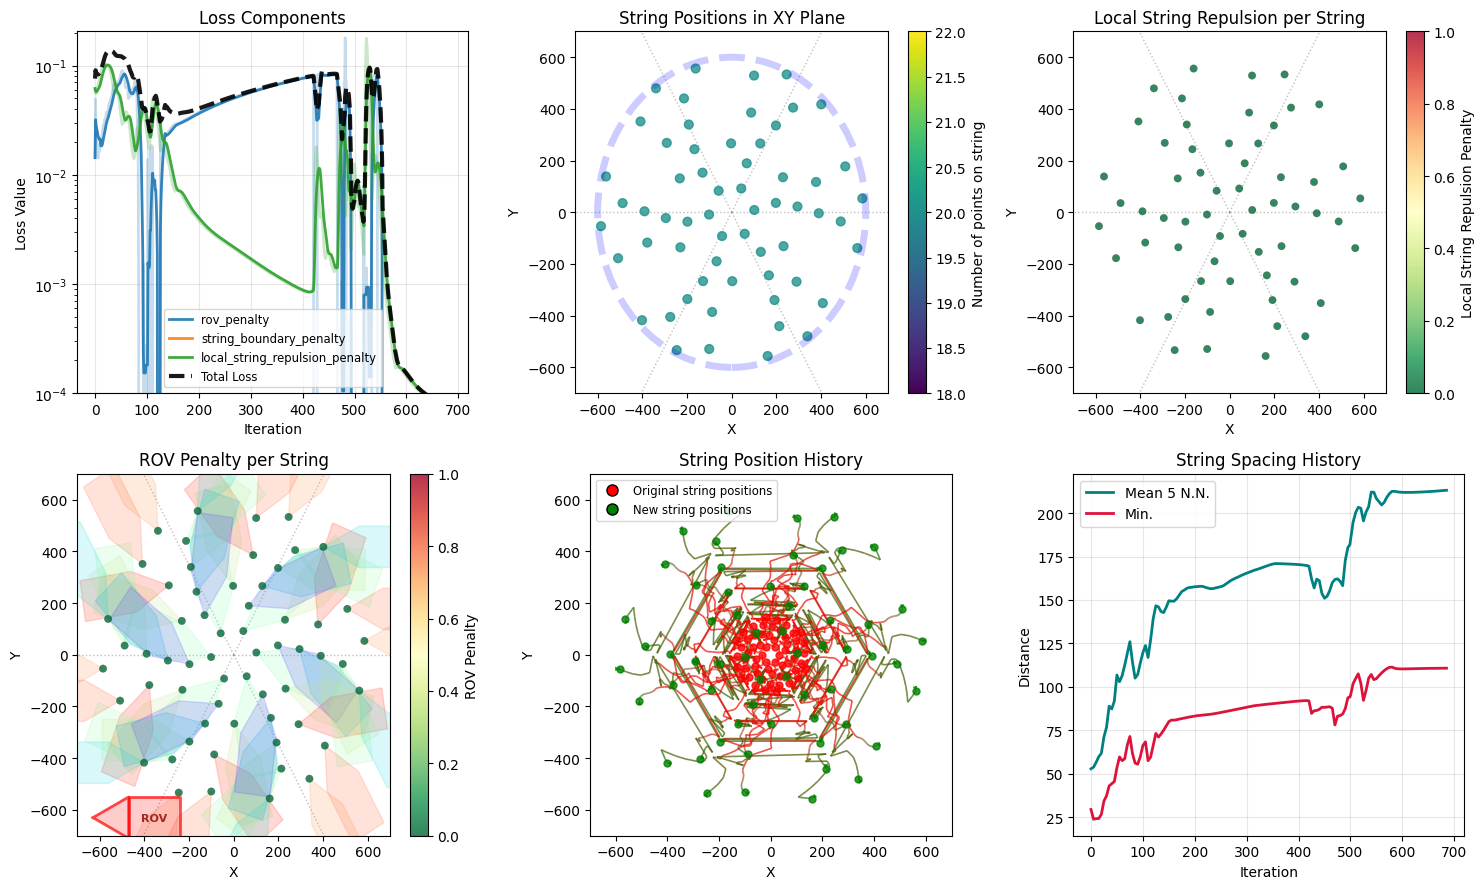

KeyboardInterrupt: 

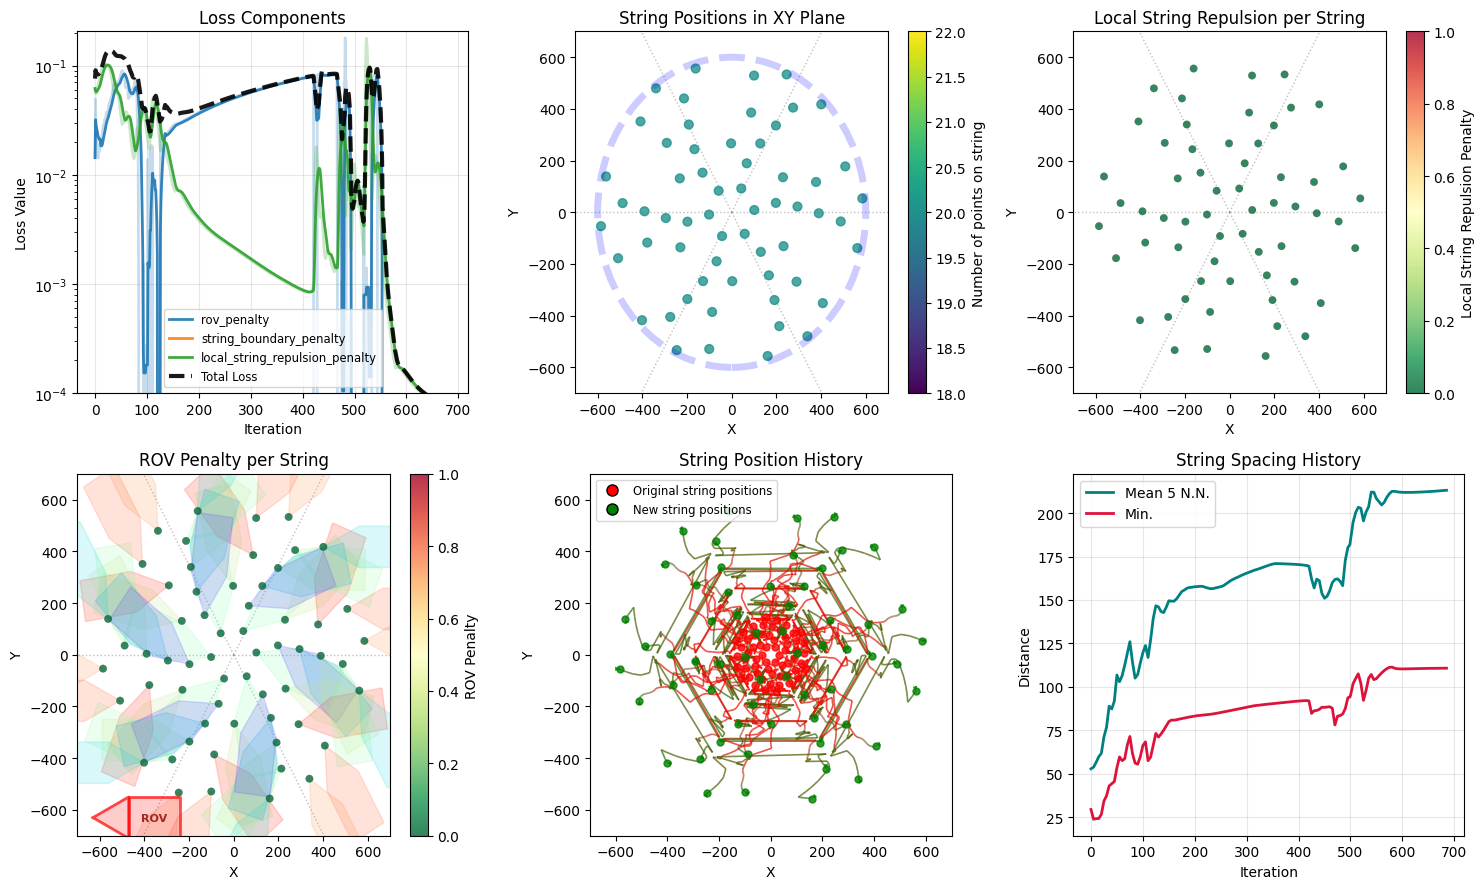

In [41]:
# optimizer.visualizer.cleanup_gif_temp_files()
torch.autograd.set_detect_anomaly(True, check_nan=True)
geom_dict = optimizer.optimize(
    clear_cuda_cache=True,
    loss_func_dict=loss_func_dict,          # Dictionary of loss functions to use
    loss_weights_dict=loss_weights_dict,    # Weights for combining multiple losses
    loss_params_dict=loss_params,           # Parameters for loss function computation
    vis_kwargs=vis_kwargs,                  # Visualization settings
    n_iter=500,                           # Maximum number of optimization iterations
    print_freq=5,                          # Print progress every N iterations
    sigmoid_loss_list=loss_sigmoid_list,         # Which losses to apply sigmoid to (for better optimization dynamics)
    vis_freq=5,                            # Frequency of visualization updates
    gif_freq=5,                           # Frequency of saving intermediate geometries
    
    revert_on_nan=True,                      # Revert geometry if loss becomes NaN
    max_nan_retries=5,  
    loss_dict=loss_dict,         # resupply loss histories if continuing optimization (only for visualization)
    uw_loss_dict=uw_loss_dict,   
    vis_loss_dict=vis_loss_dict, 
    vis_uw_loss_dict=vis_uw_loss_dict  
)


In [ ]:
optimizer.visualizer.finalize_gif(
    gif_filename='../gifs/alm_rov_boundary_repulsion_test_6fold.gif',  # Output filename
    gif_fps=10,                    # Animation frame rate
    cleanup_images=False           # Keep individual frames for debugging
)

Successfully compiled GIF '../gifs/alm_rov_boundary_repulsion_test_6fold.gif' with 138 frames.


: 